In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
# Đảm bảo hiển thị đầy đủ thông tin
pd.set_option('display.max_rows', None)


In [53]:


# Danh sách các đường dẫn file và tên DataFrame
file_paths = {
    "Brent_Crude_Oil": r"D:\PTDLKinhDoanh\Dataset\Brent_Crude_Oil_data.csv",
    "Crude_Oil": r"D:\PTDLKinhDoanh\Dataset\Crude_Oil_data.csv",
    "Heating_Oil": r"D:\PTDLKinhDoanh\Dataset\Heating_Oil_data.csv",
    "Natural_Gas": r"D:\PTDLKinhDoanh\Dataset\Natural_Gas_data.csv",
    "RBOB_Gasoline": r"D:\PTDLKinhDoanh\Dataset\RBOB_Gasoline_data.csv"
}

# Tạo dictionary để lưu các DataFrame
df = {name: pd.read_csv(path) for name, path in file_paths.items()}

# Truy cập các DataFrame từ dictionary
df_Brent_Crude_Oil = df["Brent_Crude_Oil"]
df_Crude_Oil = df["Crude_Oil"]
df_Heating_Oil = df["Heating_Oil"]
df_Natural_Gas = df["Natural_Gas"]
df_RBOB_Gasoline = df["RBOB_Gasoline"]

# Ví dụ: In thông tin của DataFrame "Brent_Crude_Oil"
print(df["Brent_Crude_Oil"].head())

         date       open       high        low      close  volume
0  2007-07-30  75.849998  76.529999  75.440002  75.739998    2575
1  2007-07-31  75.699997  77.169998  75.669998  77.050003    3513
2  2007-08-01  77.000000  77.059998  74.860001  75.349998    3930
3  2007-08-02  75.220001  76.209999  74.269997  75.760002    6180
4  2007-08-03  75.389999  76.000000  74.529999  74.750000    4387


In [54]:
df_Brent_Crude_Oil.head(5)

,date,open,high,low,close,volume
0,2007-07-30,75.849998,76.529999,75.440002,75.739998,2575
1,2007-07-31,75.699997,77.169998,75.669998,77.050003,3513
2,2007-08-01,77.000000,77.059998,74.860001,75.349998,3930
3,2007-08-02,75.220001,76.209999,74.269997,75.760002,6180
4,2007-08-03,75.389999,76.000000,74.529999,74.750000,4387


In [55]:
for name, dataframe in df.items():
    print(f"Các cột trong DataFrame '{name}':")
    print(dataframe.columns)
    print("-" * 50)

Các cột trong DataFrame 'Brent_Crude_Oil':
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
--------------------------------------------------
Các cột trong DataFrame 'Crude_Oil':
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
--------------------------------------------------
Các cột trong DataFrame 'Heating_Oil':
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
--------------------------------------------------
Các cột trong DataFrame 'Natural_Gas':
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
--------------------------------------------------
Các cột trong DataFrame 'RBOB_Gasoline':
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
--------------------------------------------------


In [56]:
# 5. Kiểm tra missing values
for name, dataframe in df.items():
    print(f"\nMissing values of'{name}':")
    print(dataframe.isnull().sum())
    print("-" * 50)






Missing values of'Brent_Crude_Oil':
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64
--------------------------------------------------

Missing values of'Crude_Oil':
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64
--------------------------------------------------

Missing values of'Heating_Oil':
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64
--------------------------------------------------

Missing values of'Natural_Gas':
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64
--------------------------------------------------

Missing values of'RBOB_Gasoline':
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64
--------------------------------------------------


In [57]:
# Duyệt qua dictionary để xử lý cột 'date' cho tất cả DataFrame
for name, dataframe in df.items():
    dataframe['date'] = pd.to_datetime(dataframe['date'])  # Chuyển đổi cột 'date' thành datetime
    dataframe.set_index('date', inplace=True)             # Đặt 'date' làm index
    dataframe.sort_index(inplace=True)                    # Sắp xếp theo index
    print(f"Đã xử lý DataFrame: {name}")

Đã xử lý DataFrame: Brent_Crude_Oil
Đã xử lý DataFrame: Crude_Oil
Đã xử lý DataFrame: Heating_Oil
Đã xử lý DataFrame: Natural_Gas
Đã xử lý DataFrame: RBOB_Gasoline


In [58]:
# Trích xuất thêm thông tin từ ngày cho tất cả DataFrame trong dictionary
for name, dataframe in df.items():
    dataframe['year'] = dataframe.index.year
    dataframe['month'] = dataframe.index.month
    dataframe['day'] = dataframe.index.day
    print(f"Đã trích xuất thông tin ngày cho DataFrame: {name}")

Đã trích xuất thông tin ngày cho DataFrame: Brent_Crude_Oil
Đã trích xuất thông tin ngày cho DataFrame: Crude_Oil
Đã trích xuất thông tin ngày cho DataFrame: Heating_Oil
Đã trích xuất thông tin ngày cho DataFrame: Natural_Gas
Đã trích xuất thông tin ngày cho DataFrame: RBOB_Gasoline


In [59]:
columns = ['open', 'high', 'low', 'close', 'volume']

# Duyệt qua từng DataFrame trong dictionary
for name, dataframe in df.items():
    print(f"\nKiểm tra DataFrame: {name}")
    for col in columns:
        if col in dataframe.columns:  # Kiểm tra nếu cột tồn tại
            if pd.api.types.is_numeric_dtype(dataframe[col]):
                print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (dataframe[col] <= 0).sum())
            else:
                print(f"Cột {col} không phải số, bỏ qua.")
        else:
            print(f"Cột {col} không tồn tại trong DataFrame {name}.")


Kiểm tra DataFrame: Brent_Crude_Oil
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 7

Kiểm tra DataFrame: Crude_Oil
Giá trị open nhỏ hơn hoặc bằng 0: 1
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 2
Giá trị close nhỏ hơn hoặc bằng 0: 1
Giá trị volume nhỏ hơn hoặc bằng 0: 7

Kiểm tra DataFrame: Heating_Oil
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 9

Kiểm tra DataFrame: Natural_Gas
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 9

Kiểm tra DataFrame: RBOB_Gasoline
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0

In [60]:
# Duyệt qua từng DataFrame trong dictionary
for name, dataframe in df.items():
    print(f"Đang xử lý DataFrame: {name}")
    for col in ['open', 'high', 'low', 'close']:
        if col in dataframe.columns:  # Kiểm tra nếu cột tồn tại
            mean_value = dataframe[col][dataframe[col] > 0].mean()  # Tính giá trị trung bình của các giá trị > 0
            dataframe[col] = dataframe[col].apply(lambda x: x if x > 0 else mean_value)  # Thay thế giá trị
            print(f"Đã xử lý cột: {col}")
        else:
            print(f"Cột {col} không tồn tại trong DataFrame {name}.")

Đang xử lý DataFrame: Brent_Crude_Oil
Đã xử lý cột: open
Đã xử lý cột: high
Đã xử lý cột: low
Đã xử lý cột: close
Đang xử lý DataFrame: Crude_Oil
Đã xử lý cột: open
Đã xử lý cột: high
Đã xử lý cột: low
Đã xử lý cột: close
Đang xử lý DataFrame: Heating_Oil
Đã xử lý cột: open
Đã xử lý cột: high
Đã xử lý cột: low
Đã xử lý cột: close
Đang xử lý DataFrame: Natural_Gas
Đã xử lý cột: open
Đã xử lý cột: high
Đã xử lý cột: low
Đã xử lý cột: close
Đang xử lý DataFrame: RBOB_Gasoline
Đã xử lý cột: open
Đã xử lý cột: high
Đã xử lý cột: low
Đã xử lý cột: close


In [61]:
columns = ['open', 'high', 'low', 'close', 'volume']

# Duyệt qua từng DataFrame trong dictionary
for name, dataframe in df.items():
    print(f"\nKiểm tra DataFrame: {name}")
    for col in columns:
        if col in dataframe.columns:  # Kiểm tra nếu cột tồn tại
            if pd.api.types.is_numeric_dtype(dataframe[col]):
                print(f"Giá trị {col} nhỏ hơn hoặc bằng 0:", (dataframe[col] <= 0).sum())
            else:
                print(f"Cột {col} không phải số, bỏ qua.")
        else:
            print(f"Cột {col} không tồn tại trong DataFrame {name}.")


Kiểm tra DataFrame: Brent_Crude_Oil
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 7

Kiểm tra DataFrame: Crude_Oil
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 7

Kiểm tra DataFrame: Heating_Oil
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 9

Kiểm tra DataFrame: Natural_Gas
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0: 0
Giá trị close nhỏ hơn hoặc bằng 0: 0
Giá trị volume nhỏ hơn hoặc bằng 0: 9

Kiểm tra DataFrame: RBOB_Gasoline
Giá trị open nhỏ hơn hoặc bằng 0: 0
Giá trị high nhỏ hơn hoặc bằng 0: 0
Giá trị low nhỏ hơn hoặc bằng 0

In [62]:
# Nếu lỡ đánh date thành index, bỏ index cho cột date bằng cách sau
for name, dataframe in df.items():
    dataframe.reset_index(inplace=True)           
    dataframe.sort_index(inplace=True)                   
    print(f"Đã xử lý DataFrame: {name}")

Đã xử lý DataFrame: Brent_Crude_Oil
Đã xử lý DataFrame: Crude_Oil
Đã xử lý DataFrame: Heating_Oil
Đã xử lý DataFrame: Natural_Gas
Đã xử lý DataFrame: RBOB_Gasoline


In [63]:
from sklearn.model_selection import train_test_split

# Định nghĩa các đặc trưng và mục tiêu
features = ['open', 'high', 'low', 'volume', 'year', 'month', 'day']
target = 'close'

# Dictionary để lưu kết quả chia dữ liệu
split_data = {}

# Duyệt qua từng DataFrame trong dictionary
for name, dataframe in df.items():
    print(f"Đang xử lý DataFrame: {name}")
    if all(col in dataframe.columns for col in features + [target]):  # Kiểm tra nếu tất cả cột tồn tại
        X = dataframe[features]
        y = dataframe[target]
        
        # Chia dữ liệu thành tập huấn luyện và tập kiểm tra
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Lưu kết quả vào dictionary
        split_data[name] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test
        }
        print(f"Đã chia dữ liệu cho DataFrame: {name}")
    else:
        print(f"DataFrame {name} không chứa đủ các cột cần thiết.")

Đang xử lý DataFrame: Brent_Crude_Oil
Đã chia dữ liệu cho DataFrame: Brent_Crude_Oil
Đang xử lý DataFrame: Crude_Oil
Đã chia dữ liệu cho DataFrame: Crude_Oil
Đang xử lý DataFrame: Heating_Oil
Đã chia dữ liệu cho DataFrame: Heating_Oil
Đang xử lý DataFrame: Natural_Gas
Đã chia dữ liệu cho DataFrame: Natural_Gas
Đang xử lý DataFrame: RBOB_Gasoline
Đã chia dữ liệu cho DataFrame: RBOB_Gasoline


In [64]:
from catboost import CatBoostRegressor

# Dictionary để lưu kết quả dự đoán
predictions = {}

# Duyệt qua từng DataFrame trong split_data
for name, data in split_data.items():
    print(f"Đang huấn luyện mô hình cho DataFrame: {name}")
    
    # Lấy dữ liệu huấn luyện và kiểm tra
    X_train, X_test = data['X_train'], data['X_test']
    y_train, y_test = data['y_train'], data['y_test']
    
    # Khởi tạo mô hình
    model = CatBoostRegressor(
        iterations=1000,
        depth=6,
        learning_rate=0.1,  # 0.05
        loss_function='RMSE',
        verbose=0
    )
    
    # Huấn luyện mô hình
    model.fit(X_train, y_train)
    model.save_model(f'catboost_model_{name}.cbm')
    print(f"Đã lưu mô hình: catboost_model_{name}.cbm")
    
    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)
    
    # Lưu kết quả dự đoán
    predictions[name] = {
        'y_test': y_test,
        'y_pred': y_pred
    }
    print(f"Đã hoàn thành huấn luyện và dự đoán cho DataFrame: {name}")

Đang huấn luyện mô hình cho DataFrame: Brent_Crude_Oil
Đã lưu mô hình: catboost_model_Brent_Crude_Oil.cbm
Đã hoàn thành huấn luyện và dự đoán cho DataFrame: Brent_Crude_Oil
Đang huấn luyện mô hình cho DataFrame: Crude_Oil
Đã lưu mô hình: catboost_model_Crude_Oil.cbm
Đã hoàn thành huấn luyện và dự đoán cho DataFrame: Crude_Oil
Đang huấn luyện mô hình cho DataFrame: Heating_Oil
Đã lưu mô hình: catboost_model_Heating_Oil.cbm
Đã hoàn thành huấn luyện và dự đoán cho DataFrame: Heating_Oil
Đang huấn luyện mô hình cho DataFrame: Natural_Gas
Đã lưu mô hình: catboost_model_Natural_Gas.cbm
Đã hoàn thành huấn luyện và dự đoán cho DataFrame: Natural_Gas
Đang huấn luyện mô hình cho DataFrame: RBOB_Gasoline
Đã lưu mô hình: catboost_model_RBOB_Gasoline.cbm
Đã hoàn thành huấn luyện và dự đoán cho DataFrame: RBOB_Gasoline


In [65]:

# Duyệt qua từng DataFrame trong dictionary predictions
for name, result in predictions.items():
    print(f"\nĐánh giá mô hình cho DataFrame: {name}")
    
    # Lấy y_test và y_pred
    y_test = result['y_test']
    y_pred = result['y_pred']
    
    # Tính toán các chỉ số đánh giá
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # In kết quả
    print(f"📌 - Mean Absolute Error (MAE): {mae:.4f}")
    print(f"📌 - Mean Squared Error (MSE): {mse:.4f}")
    print(f"📌 - Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"📌 - R-squared (R²): {r2:.4f}")


Đánh giá mô hình cho DataFrame: Brent_Crude_Oil
📌 - Mean Absolute Error (MAE): 0.6086
📌 - Mean Squared Error (MSE): 0.8024
📌 - Root Mean Squared Error (RMSE): 0.8958
📌 - R-squared (R²): 0.9986

Đánh giá mô hình cho DataFrame: Crude_Oil
📌 - Mean Absolute Error (MAE): 0.5465
📌 - Mean Squared Error (MSE): 0.6318
📌 - Root Mean Squared Error (RMSE): 0.7949
📌 - R-squared (R²): 0.9990

Đánh giá mô hình cho DataFrame: Heating_Oil
📌 - Mean Absolute Error (MAE): 0.0174
📌 - Mean Squared Error (MSE): 0.0007
📌 - Root Mean Squared Error (RMSE): 0.0257
📌 - R-squared (R²): 0.9991

Đánh giá mô hình cho DataFrame: Natural_Gas
📌 - Mean Absolute Error (MAE): 0.0575
📌 - Mean Squared Error (MSE): 0.0087
📌 - Root Mean Squared Error (RMSE): 0.0932
📌 - R-squared (R²): 0.9982

Đánh giá mô hình cho DataFrame: RBOB_Gasoline
📌 - Mean Absolute Error (MAE): 0.0165
📌 - Mean Squared Error (MSE): 0.0006
📌 - Root Mean Squared Error (RMSE): 0.0235
📌 - R-squared (R²): 0.9990



Trực quan hóa kết quả cho DataFrame: Brent_Crude_Oil


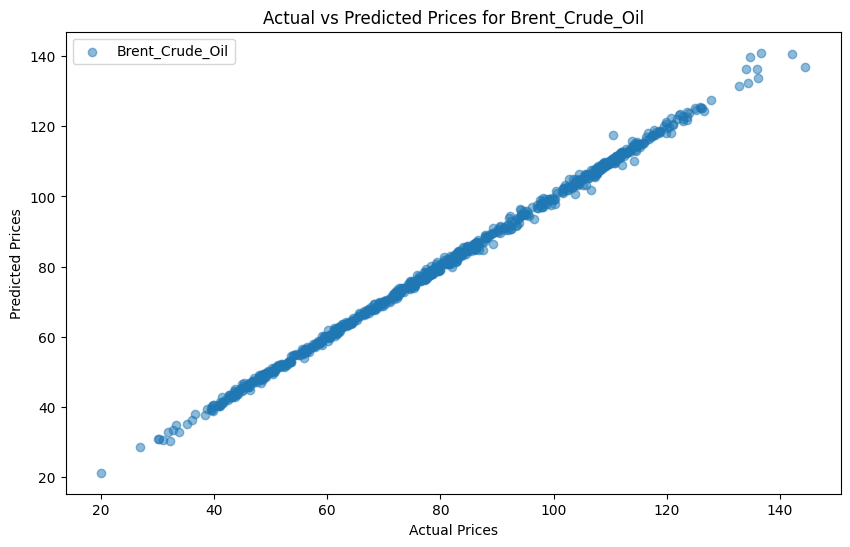


Trực quan hóa kết quả cho DataFrame: Crude_Oil


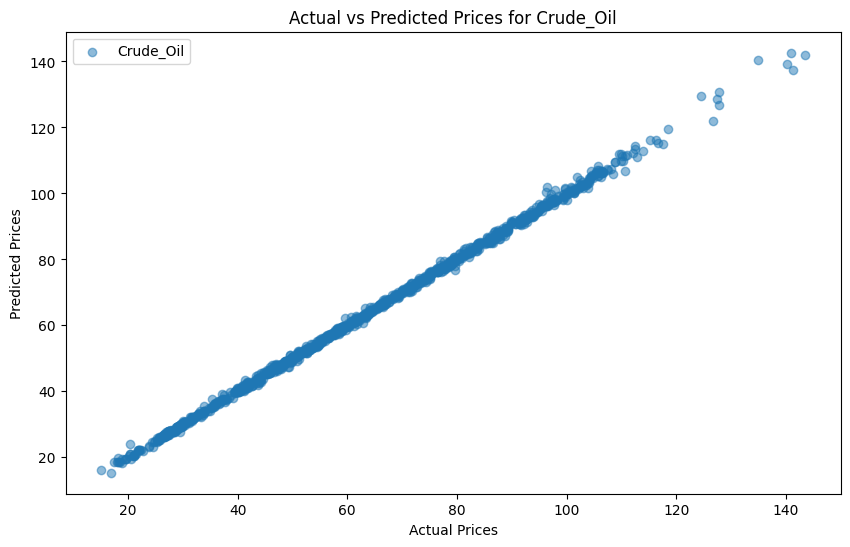


Trực quan hóa kết quả cho DataFrame: Heating_Oil


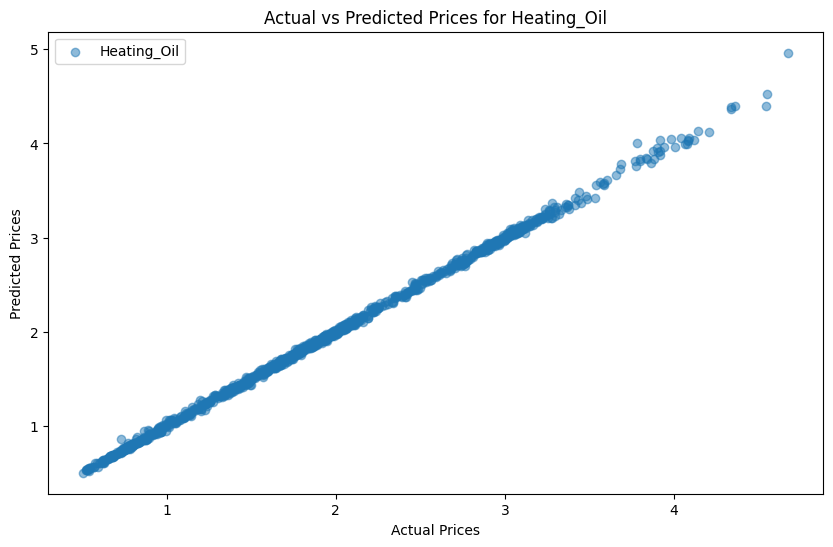


Trực quan hóa kết quả cho DataFrame: Natural_Gas


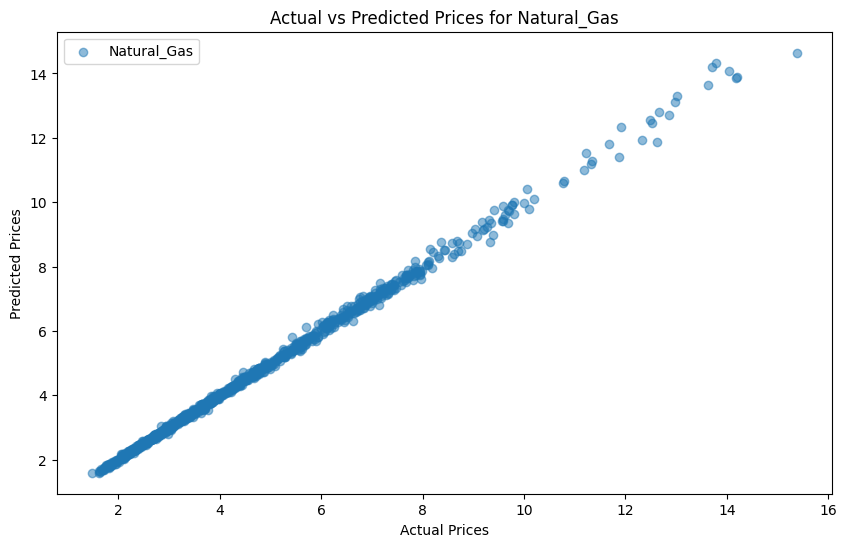


Trực quan hóa kết quả cho DataFrame: RBOB_Gasoline


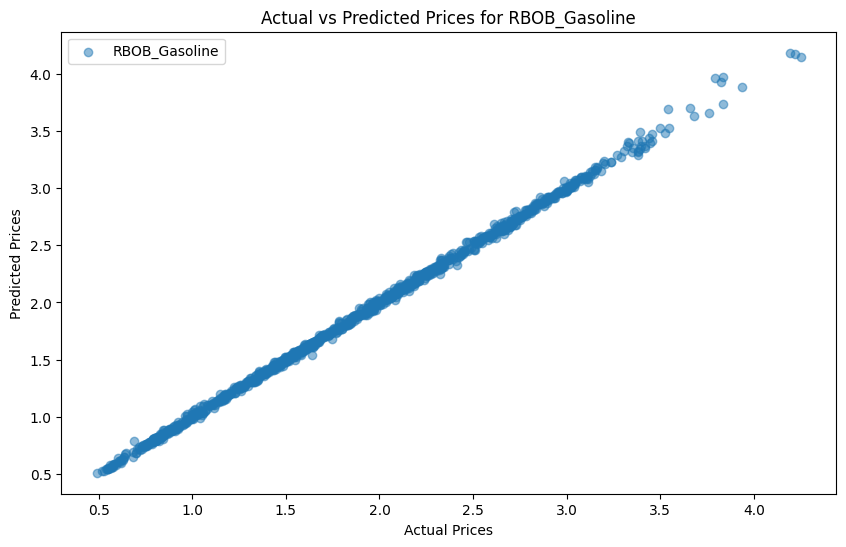

In [66]:
import matplotlib.pyplot as plt

# Duyệt qua từng DataFrame trong dictionary predictions
for name, result in predictions.items():
    print(f"\nTrực quan hóa kết quả cho DataFrame: {name}")
    
    # Lấy y_test và y_pred
    y_test = result['y_test']
    y_pred = result['y_pred']
    
    # Vẽ biểu đồ scatter
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, label=name)
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"Actual vs Predicted Prices for {name}")
    plt.legend()
    plt.show()


Trực quan hóa trung bình động cho DataFrame: Brent_Crude_Oil


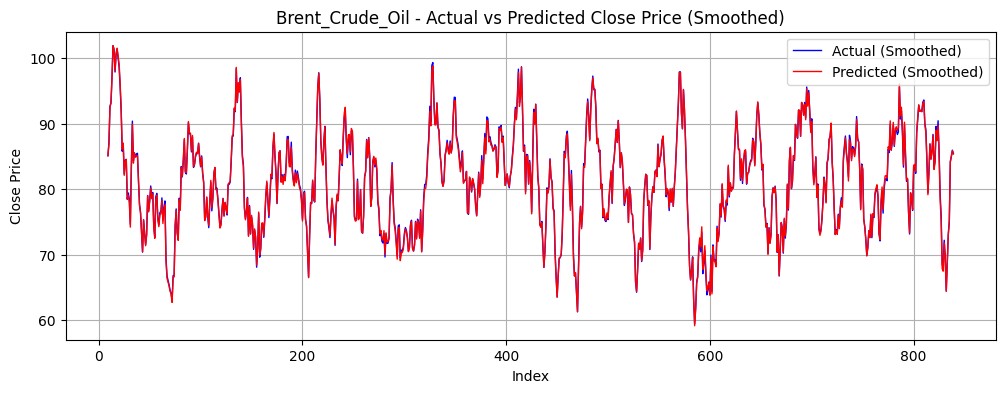


Trực quan hóa trung bình động cho DataFrame: Crude_Oil


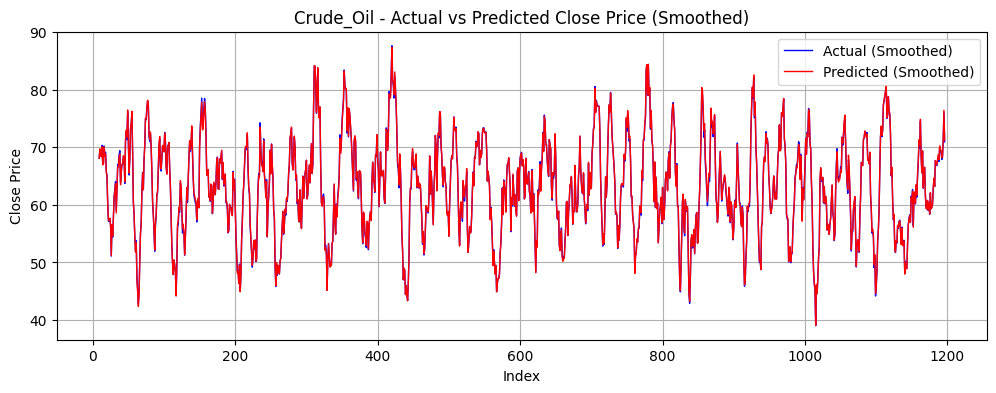


Trực quan hóa trung bình động cho DataFrame: Heating_Oil


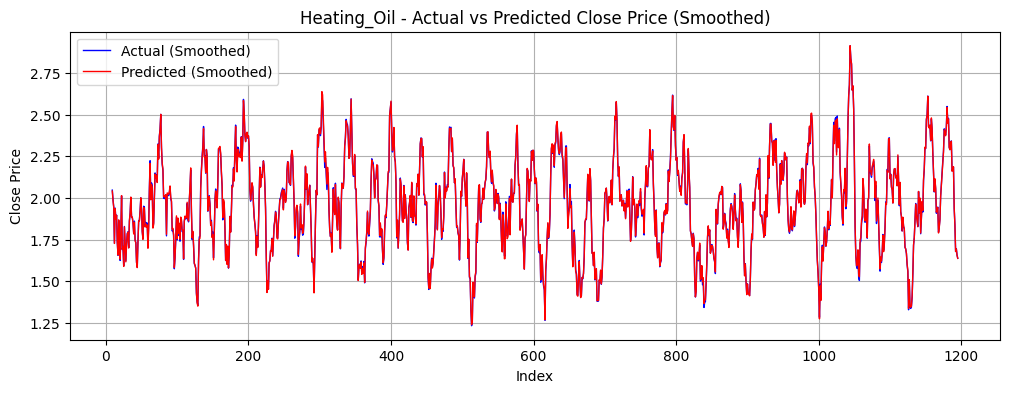


Trực quan hóa trung bình động cho DataFrame: Natural_Gas


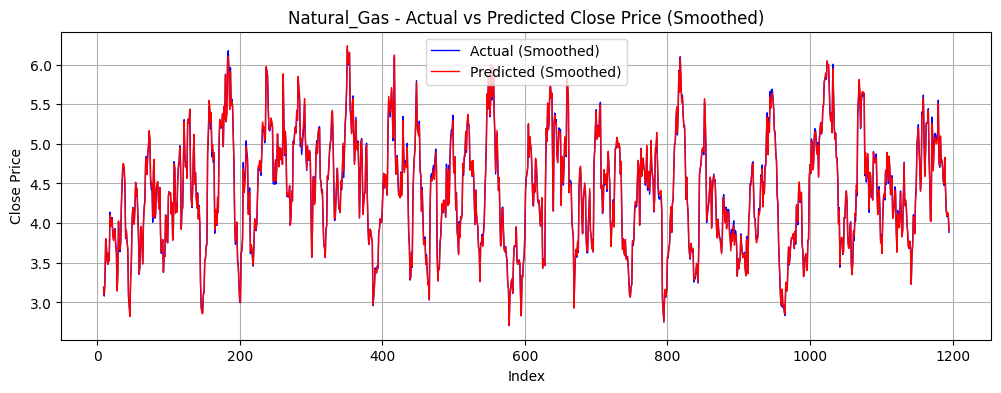


Trực quan hóa trung bình động cho DataFrame: RBOB_Gasoline


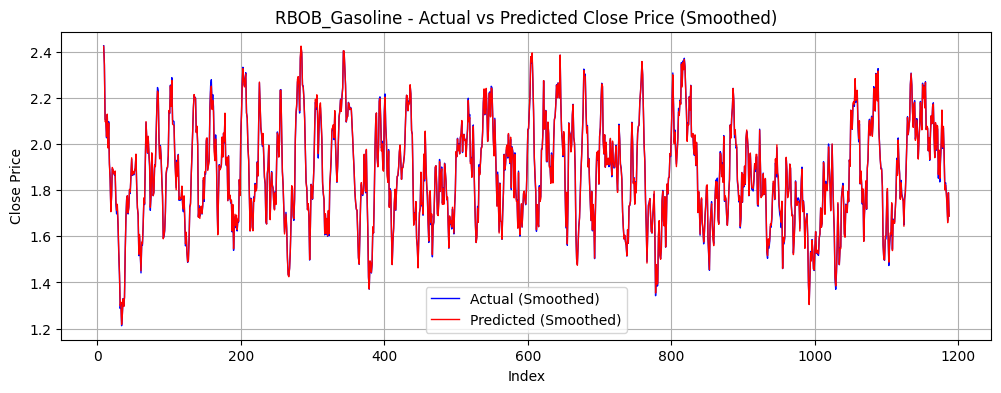

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Kích thước cửa sổ trung bình động
window_size = 10

# Duyệt qua từng DataFrame trong dictionary predictions
for name, result in predictions.items():
    print(f"\nTrực quan hóa trung bình động cho DataFrame: {name}")
    
    # Lấy y_test và y_pred
    y_test = result['y_test']
    y_pred = result['y_pred']
    
    # Tính trung bình động
    y_test_smoothed = y_test.reset_index(drop=True).rolling(window=window_size).mean()
    y_pred_smoothed = pd.Series(y_pred).rolling(window=window_size).mean()
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 4))
    plt.plot(y_test_smoothed, label='Actual (Smoothed)', color='blue', linewidth=1)
    plt.plot(y_pred_smoothed, label='Predicted (Smoothed)', color='red', linewidth=1)
    plt.title(f'{name} - Actual vs Predicted Close Price (Smoothed)')
    plt.xlabel('Index')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
model.load_model(f'catboost_model_{name}.cbm')

In [ ]:
# Function to make predictions based on user input
def predict_price(open_price, high_price, low_price, volume, year, month, day):
    input_data = np.array([[open_price, high_price, low_price, volume, year, month, day]])
    prediction = model.predict(input_data)
    print(f'Predicted Stock Price: {prediction[0]:.2f}')

# Displaying the widgets and connecting them to the prediction function
interactive_plot = widgets.interactive(predict_price, 
                                       open_price=31.950001, 
                                       high_price=32.799999, 
                                       low_price=31.950001, 
                                       volume=79385, 
                                       year=2000, 
                                       month=8, 
                                       day=23)
display(interactive_plot)
